# ASSIGNMENT 3

### Preliminary

In [13]:
import cvxpy as cp
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download historical price data for 6 tech stocks
tickers_6 = ["AAPL", "MSFT", "AMZN", "NVDA", "TSLA", "META"]

start_date = "2015-01-01"
end_date   = "2022-12-31"

raw_data = yf.download(
    tickers_6,
    start=start_date,
    end=end_date,
    progress=False
)

prices_6 = raw_data['Close'].dropna(how="all")
prices_6 = prices_6.ffill()
prices_6 = prices_6.dropna(how="any")
monthly_prices_6 = prices_6.resample("M").last() # Get last trading day of each month

# Compute monthly log returns
returns_6 = np.log(monthly_prices_6).diff().dropna(how="any")

print("Monthly returns shape (6 tickers):", returns_6.shape)
print(returns_6.head())

# For this assignment, we assume the monthly risk-free rate is zero
rf = 0.0

C:\Users\mc160\AppData\Local\Temp\ipykernel_10040\3969072479.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(


Monthly returns shape (6 tickers): (95, 6)
Ticker          AAPL      AMZN      META      MSFT      NVDA      TSLA
Date                                                                  
2015-02-28  0.096016  0.069799  0.039520  0.089036  0.142699 -0.001278
2015-03-31 -0.031875 -0.021430  0.040331 -0.075530 -0.052583 -0.074350
2015-04-30  0.005770  0.125321 -0.042866  0.179202  0.058909  0.180227
2015-05-31  0.044342  0.017509  0.005318 -0.030804  0.001460  0.103900
2015-06-30 -0.037938  0.011259  0.079819 -0.059572 -0.095717  0.067301


C:\Users\mc160\AppData\Local\Temp\ipykernel_10040\3969072479.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices_6 = prices_6.resample("M").last() # Get last trading day of each month


In [3]:
# Market capitalization weights for the 6 tech stocks

# Index Weighting” reported in the Investopedia article
global_weights = [7.1, 6.51, 3.24, 2.84, 1.87, 1.84]

# Convert percentages to decimals
global_weights = [w / 100 for w in global_weights]

# Create a DataFrame to display the weights
df = pd.DataFrame({
    'Ticker': tickers_6,
    'Global_Market_Weight': global_weights
})

# Display
print(df)

  Ticker  Global_Market_Weight
0   AAPL                0.0710
1   MSFT                0.0651
2   AMZN                0.0324
3   NVDA                0.0284
4   TSLA                0.0187
5   META                0.0184


### Q1.1
Based on the sample data on returns, first compute the Markowitz
mean-variance portfolio weights. Are these weights reasonable? Explain
why.


===== Markowitz Mean-Variance (Lagrangian Approach) =====
Lambda (risk aversion): 2.0

Optimal weights:
  Ticker  Markowitz_Weight
0   AAPL      4.075634e-23
1   MSFT      1.280477e-22
2   AMZN     -3.856485e-23
3   NVDA      7.512438e-01
4   TSLA      2.487562e-01
5   META     -1.435043e-24

Expected portfolio return (monthly): 0.0242
Portfolio variance: 0.0051
Portfolio volatility (monthly): 0.0717


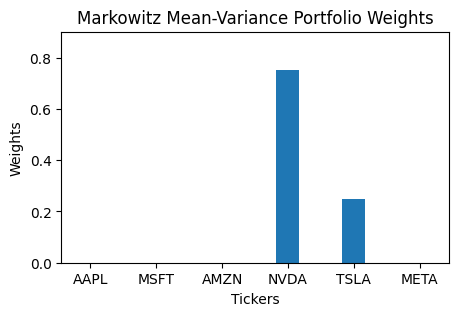

In [4]:
# Q1.1: Compute the Markowitz mean-variance portfolio weights 

# Compute mean returns and covariance matrix
mu = returns_6.mean().values  # Expected returns (monthly)
Sigma = returns_6.cov().values  # Covariance matrix
n = len(tickers_6)

# Define portfolio weights as optimization variables
w = cp.Variable(n)

# Constraints
constraints = [
    cp.sum(w) == 1,  # Weights sum to 1
    w >= 0           # No short selling
]

# ===== LAGRANGIAN APPROACH =====
# Objective: Maximize (return - lambda * variance)
# lambda controls the risk/return trade-off:
# - small lambda = more emphasis on return
# - large lambda = more emphasis on reducing risk

# Adjust depending on your risk aversion 
# Risk aversion is supposed to be equal to sharpe ratio over volatility of market
lambda_param = 2.0  

portfolio_return = mu @ w
portfolio_variance = cp.quad_form(w, Sigma)

# Lagrangian objective
objective = cp.Maximize(portfolio_return - lambda_param * portfolio_variance)

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Extract results
markowitz_weights = w.value
final_return = mu @ markowitz_weights
final_variance = markowitz_weights @ Sigma @ markowitz_weights
final_volatility = np.sqrt(final_variance)

# Display results
df_markowitz = pd.DataFrame({
    'Ticker': tickers_6,
    'Markowitz_Weight': markowitz_weights
})

print("\n===== Markowitz Mean-Variance (Lagrangian Approach) =====")
print(f"Lambda (risk aversion): {lambda_param}")
print("\nOptimal weights:")
print(df_markowitz)
print(f"\nExpected portfolio return (monthly): {final_return:.4f}")
print(f"Portfolio variance: {final_variance:.4f}")
print(f"Portfolio volatility (monthly): {final_volatility:.4f}")

plt.figure(figsize=(5,3))
bar_width = 0.35
index = tickers_6
plt.bar(index, markowitz_weights, bar_width, label='Markowitz Weights')
plt.title('Markowitz Mean-Variance Portfolio Weights')
plt.xlabel('Tickers')
plt.ylabel('Weights')
plt.ylim(0, max(markowitz_weights)*1.2)
plt.show()

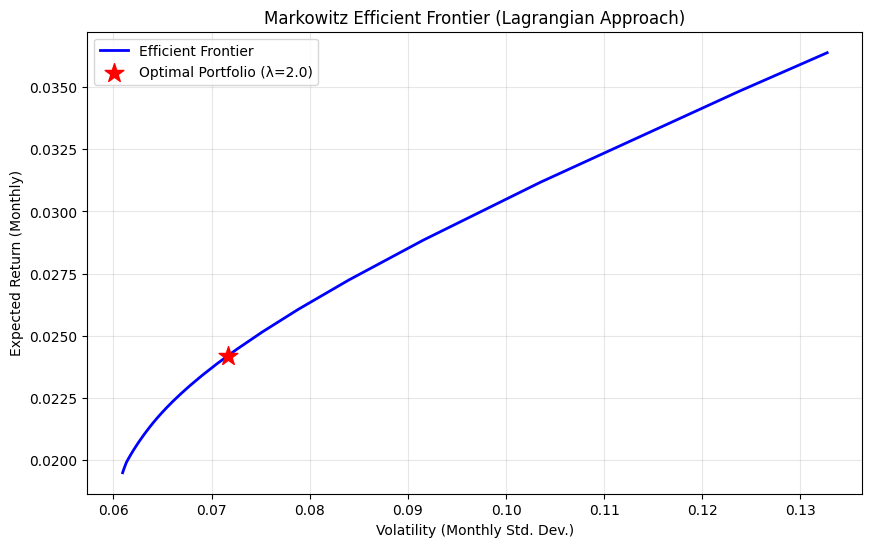


===== Efficient Frontier (first and last portfolios) =====
     Lambda    Return  Volatility
0  0.100000  0.036379    0.132725
1  0.302041  0.036379    0.132725
2  0.504082  0.036379    0.132725
3  0.706122  0.034822    0.123717
4  0.908163  0.031171    0.103493
...
       Lambda    Return  Volatility
45   9.191837  0.019633    0.061048
46   9.393878  0.019598    0.061017
47   9.595918  0.019564    0.060988
48   9.797959  0.019531    0.060961
49  10.000000  0.019500    0.060935


In [5]:
# ===== BONUS: Efficient Frontier =====
# Compute multiple portfolios for different lambda values

lambdas = np.linspace(0.1, 10, 50)
efficient_frontier = []

for lam in lambdas:
    w_temp = cp.Variable(n)
    constraints_temp = [cp.sum(w_temp) == 1, w_temp >= 0]
    objective_temp = cp.Maximize(mu @ w_temp - lam * cp.quad_form(w_temp, Sigma))
    problem_temp = cp.Problem(objective_temp, constraints_temp)
    problem_temp.solve()
    
    ret = mu @ w_temp.value
    vol = np.sqrt(w_temp.value @ Sigma @ w_temp.value)
    efficient_frontier.append({'Lambda': lam, 'Return': ret, 'Volatility': vol})

df_frontier = pd.DataFrame(efficient_frontier)

# Plot efficient frontier
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_frontier['Volatility'], df_frontier['Return'], 'b-', linewidth=2, label='Efficient Frontier')
plt.scatter(final_volatility, final_return, s=200, marker='*', color='red',
            label=f'Optimal Portfolio (λ={lambda_param})', zorder=5)
plt.xlabel('Volatility (Monthly Std. Dev.)')
plt.ylabel('Expected Return (Monthly)')
plt.title('Markowitz Efficient Frontier (Lagrangian Approach)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n===== Efficient Frontier (first and last portfolios) =====")
print(df_frontier.head())
print("...")
print(df_frontier.tail())

### **Interpretation**

The resulting portfolio weights are reasonable when viewed through the Markowitz mean-variance framework.
With the objective
$$
\max_w \; \mu^\top w - \lambda \, w^\top \Sigma w
$$
and long-only weights summing to 1, the optimizer allocates capital to the assets with the highest risk-adjusted expected returns.

NVDA and TSLA receive all the weight because, in the sample, they exhibit the strongest return–variance trade-off. Since short-selling is not allowed, the model cannot hedge using low-return assets, leading to a concentrated “corner solution,” exactly as described in the lecture (slides ~35–47).

The extremely small values on AAPL, MSFT, AMZN, and META are numerical zeros: economically, the model sets $w_i = 0$ for these assets.

With a moderate risk-aversion parameter ($\lambda = 2$), the optimizer still emphasizes expected return, which explains the heavy concentration. The resulting expected return and volatility are consistent with a high-growth tech allocation.

**Conclusion:**
The weights are consistent with the long-only Markowitz mean-variance model: when assets have very different expected returns, the optimal portfolio naturally invests only in the most attractive ones.


### Q1.2
Based on the data on index weighting (or market capitalization) you have
downloaded, write down the “market” weights of a portfolio that invests
in only AAPL, MSFT, AMZN, NVDA, TESLA, and META.

===== Market Portfolio Weights =====
  Ticker  Market_Weight
0   AAPL       0.303419
1   MSFT       0.278205
2   AMZN       0.138462
3   NVDA       0.121368
4   TSLA       0.079915
5   META       0.078632

Sum of weights: 1.0000


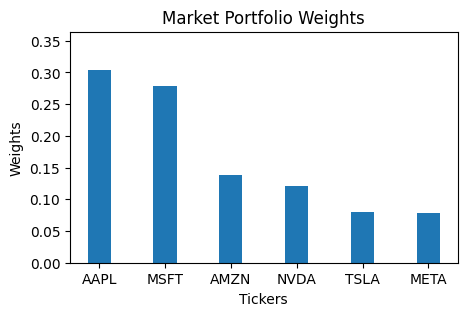

In [6]:
# Q1.2: Compute market weights from global market weights

# The global_weights are already defined in cell 5

# Normalize the weights so they sum to 1 (for our 6-stock portfolio)
total_weight = sum(global_weights)
market_weights = [w / total_weight for w in global_weights]

# Create a DataFrame to display the market portfolio weights
df_market = pd.DataFrame({
    'Ticker': tickers_6,
    'Market_Weight': market_weights
})

print("===== Market Portfolio Weights =====")
print(df_market)
print(f"\nSum of weights: {sum(market_weights):.4f}")

plt.figure(figsize=(5,3))
bar_width = 0.35
index = tickers_6
plt.bar(index, market_weights, bar_width, label='Market Weights')
plt.title('Market Portfolio Weights')
plt.xlabel('Tickers')
plt.ylabel('Weights')
plt.ylim(0, max(market_weights)*1.2)
plt.show()

Finally, we will compute the Black-Litterman portfolio weights. We will do this in several small steps.

### Q1.3
Step 1: Using the market-capitalization weights you have downloaded,
calculate the CAPM-implied expected returns.


In [7]:
# Q1.3: Calculate CAPM-implied expected returns

# Market portfolio weights (already normalized)
w_m = np.array(market_weights)

# Calculate market portfolio return
mu_m = mu @ w_m

# Calculate market portfolio variance
sigma_m_squared = w_m @ Sigma @ w_m

# Calculate betas for each asset
# Beta_i = Cov(R_i, R_m) / Var(R_m)
# Cov(R_i, R_m) = Sigma_i · w_m
cov_with_market = Sigma @ w_m
betas = cov_with_market / sigma_m_squared

# CAPM-implied expected returns
# E[R_i] = r_f + beta_i * (E[R_m] - r_f)
# Since r_f = 0:
# E[R_i] = beta_i * E[R_m]
mu_capm = betas * mu_m

# Display results
df_capm = pd.DataFrame({
    'Ticker': tickers_6,
    'Market_Weight': market_weights,
    'Beta': betas,
    'CAPM_Expected_Return': mu_capm,
    'Sample_Expected_Return': mu
})

print("===== CAPM-Implied Expected Returns =====")
print(f"Market portfolio return (monthly): {mu_m:.4f}")
print(f"Market portfolio variance: {sigma_m_squared:.4f}")
print(f"Market portfolio volatility (monthly): {np.sqrt(sigma_m_squared):.4f}\n")
print(df_capm)

===== CAPM-Implied Expected Returns =====
Market portfolio return (monthly): 0.0175
Market portfolio variance: 0.0054
Market portfolio volatility (monthly): 0.0733

  Ticker  Market_Weight      Beta  CAPM_Expected_Return  \
0   AAPL       0.303419  0.962425              0.016846   
1   MSFT       0.278205  1.038400              0.018176   
2   AMZN       0.138462  0.832088              0.014565   
3   NVDA       0.121368  0.677260              0.011854   
4   TSLA       0.079915  1.317236              0.023056   
5   META       0.078632  1.480537              0.025915   

   Sample_Expected_Return  
0                0.016789  
1                0.016376  
2                0.004850  
3                0.020180  
4                0.036379  
5                0.023216  


### Q1.4
Step 2: Specify the pick matrix P and the view vector q that captures the
following views for each of the assets:
##### AAPL: its absolute excess return is expected to be 10% per year.
##### MSFT: its absolute excess return is expected to be 5% per year.
##### AMZN: no views
##### NVDA will outperform TSLA by 2% per year.
##### TSLA will underperform META by 1% per year.
Finally, explain your choice for the matrix Ω, which captures the
uncertainty about these views. (There are different ways to specify this
matrix, so feel free to choose anything reasonable.)

In [8]:
# Q1.4: Specify the pick matrix P and view vector q for Black-Litterman

# We have 4 views to specify
# Convert annual returns to monthly by dividing by 12
# Order of assets: AAPL, MSFT, AMZN, NVDA, TSLA, META

P = np.array([
    [1, 0, 0, 0, 0, 0],      # View 1: AAPL
    [0, 1, 0, 0, 0, 0],      # View 2: MSFT
    [0, 0, 0, 1, -1, 0],     # View 4: NVDA - TSLA
    [0, 0, 0, 0, 1, -1]      # View 5: TSLA - META => -1% p.a. negative view
])

# View vector q (in monthly terms)
q = np.array([
    0.10 / 12,   # AAPL: 10% annual → monthly
    0.05 / 12,   # MSFT: 5% annual → monthly
    0.02 / 12,   # NVDA - TSLA: 2% annual → monthly
    -0.01 / 12   # TSLA - META: -1% annual → monthly
])

print("===== Black-Litterman Views =====")
print("\nPick matrix P (4 views × 6 assets):")
print(pd.DataFrame(P, columns=tickers_6, 
                   index=['AAPL = 10% p.a.', 'MSFT = 5% p.a.', 
                          'NVDA - TSLA = 2% p.a.', 'TSLA - META = -1% p.a.']))

print("\nView vector q (monthly returns):")
print(pd.DataFrame({'View': ['AAPL = 10% p.a.', 'MSFT = 5% p.a.', 
                              'NVDA - TSLA = 2% p.a.', 'TSLA - META = -1% p.a.'],
                    'Monthly_Return': q,
                    'Annual_Return': q * 12}))

===== Black-Litterman Views =====

Pick matrix P (4 views × 6 assets):
                        AAPL  MSFT  AMZN  NVDA  TSLA  META
AAPL = 10% p.a.            1     0     0     0     0     0
MSFT = 5% p.a.             0     1     0     0     0     0
NVDA - TSLA = 2% p.a.      0     0     0     1    -1     0
TSLA - META = -1% p.a.     0     0     0     0     1    -1

View vector q (monthly returns):
                     View  Monthly_Return  Annual_Return
0         AAPL = 10% p.a.        0.008333           0.10
1          MSFT = 5% p.a.        0.004167           0.05
2   NVDA - TSLA = 2% p.a.        0.001667           0.02
3  TSLA - META = -1% p.a.       -0.000833          -0.01


In [9]:
# Q1.4 (continued): Specify the uncertainty matrix Omega

# Omega captures the uncertainty/confidence in our views

# Approach from the slides: Proportional to the variance of the view portfolios
# Omega_ii = tau * P_i * Sigma * P_i^T

# tau is a scalar representing overall uncertainty
# from the slides: tau = 1 / T, where T is the number of observations used to estimate returns
T_est = len(returns_6)  # Number of data points (monthly returns)
tau = 1.0 / T_est

# Calculate Omega as a diagonal matrix
# For each view i: Omega_ii = tau * P_i * Sigma * P_i^T
Omega = np.zeros((len(q), len(q)))

for i in range(len(q)):
    P_i = P[i, :].reshape(1, -1)  # i-th row of P
    Omega[i, i] = tau * (P_i @ Sigma @ P_i.T)[0, 0]

print("===== View Uncertainty Matrix Omega =====")
print(f"\nNumber of observations T: {T_est}")
print(f"Scalar tau (overall uncertainty): {tau:.6f} (= 1/T)")
print(f"\nOmega matrix (4 × 4):")
print(pd.DataFrame(Omega, 
                   index=['AAPL = 10% p.a.', 'MSFT = 5% p.a.', 
                          'NVDA - TSLA = 2% p.a.', 'TSLA - META = -1% p.a.'],
                   columns=['AAPL = 10% p.a.', 'MSFT = 5% p.a.', 
                            'NVDA - TSLA = 2% p.a.', 'TSLA - META = -1% p.a.']))

print("\n===== Interpretation =====")
print("We use the approach given in the course notes: Ω_ii = τ × P_i Σ P_i^T")
print(f"- τ = 1/T = 1/{T_est} = {tau:.6f} represents uncertainty about the equilibrium")
print("- T is the number of observations used to estimate the covariance matrix")
print("- Each diagonal entry reflects the variance of the corresponding view portfolio")
print("- Views on more volatile assets (or portfolios) have larger uncertainty")
print("- Off-diagonal elements are zero (views are assumed independent)")

===== View Uncertainty Matrix Omega =====

Number of observations T: 95
Scalar tau (overall uncertainty): 0.010526 (= 1/T)

Omega matrix (4 × 4):
                        AAPL = 10% p.a.  MSFT = 5% p.a.  \
AAPL = 10% p.a.                0.000073        0.000000   
MSFT = 5% p.a.                 0.000000        0.000085   
NVDA - TSLA = 2% p.a.          0.000000        0.000000   
TSLA - META = -1% p.a.         0.000000        0.000000   

                        NVDA - TSLA = 2% p.a.  TSLA - META = -1% p.a.  
AAPL = 10% p.a.                      0.000000                0.000000  
MSFT = 5% p.a.                       0.000000                0.000000  
NVDA - TSLA = 2% p.a.                0.000119                0.000000  
TSLA - META = -1% p.a.               0.000000                0.000323  

===== Interpretation =====
We use the approach given in the course notes: Ω_ii = τ × P_i Σ P_i^T
- τ = 1/T = 1/95 = 0.010526 represents uncertainty about the equilibrium
- T is the number of observ

### Q1.5 
Step 3: Use these views to compute the conditional expected excess
returns (µBL) and covariance matrix of excess returns (ΣBL).


In [10]:
# Q1.5: Compute Black-Litterman posterior expected returns and covariance matrix

# Following the Black-Litterman formula from the course:
# Equation (10): μ_BL = [(τΣ)^(-1) + P^T Ω^(-1) P]^(-1) [(τΣ)^(-1) μ_CAPM + P^T Ω^(-1) q]
# Equation (11): Σ_BL = Σ + [(τΣ)^(-1) + P^T Ω^(-1) P]^(-1)

# Step 1: Compute intermediate matrices
tau_Sigma = tau * Sigma
tau_Sigma_inv = np.linalg.inv(tau_Sigma)
Omega_inv = np.linalg.inv(Omega)

# Step 2: Compute M = [(τΣ)^(-1) + P^T Ω^(-1) P]^(-1)
M = np.linalg.inv(tau_Sigma_inv + P.T @ Omega_inv @ P)

# Step 3: Compute posterior expected returns μ_BL
mu_BL = M @ (tau_Sigma_inv @ mu_capm + P.T @ Omega_inv @ q)

# Step 4: Compute posterior covariance matrix Σ_BL
Sigma_BL = Sigma + M

# Display results
print("===== Black-Litterman Conditional Expected Returns =====")
df_bl_returns = pd.DataFrame({
    'Ticker': tickers_6,
    'CAPM_Prior': mu_capm,
    'BL_Posterior': mu_BL,
    'Difference': mu_BL - mu_capm
})
print(df_bl_returns)

print("\n===== Black-Litterman Conditional Covariance Matrix =====")
print("Σ_BL:")
print(pd.DataFrame(Sigma_BL, 
                   index=tickers_6, 
                   columns=tickers_6))

print("\n===== Comparison of Variances =====")
df_cov_comparison = pd.DataFrame({
    'Ticker': tickers_6,
    'Sample_Variance': np.diag(Sigma),
    'BL_Variance': np.diag(Sigma_BL),
    'Variance_Increase': np.diag(Sigma_BL) - np.diag(Sigma)
})
print(df_cov_comparison)

print("\n===== Interpretation =====")
print("The Black-Litterman model combines:")
print("1. Prior (CAPM equilibrium): μ_CAPM based on market weights")
print("2. Views: Our 4 subjective views on expected returns")
print("3. Uncertainty: Ω matrix reflecting confidence in our views")
print(f"\nThe conditional expected returns μ_BL blend the prior and views,")
print(f"weighted by their relative precision (inverse uncertainty).")
print(f"\nThe conditional covariance Σ_BL = Σ + M reflects additional uncertainty")
print(f"from estimation error (controlled by τ = {tau:.6f}).")

===== Black-Litterman Conditional Expected Returns =====
  Ticker  CAPM_Prior  BL_Posterior  Difference
0   AAPL    0.016846      0.010334   -0.006512
1   MSFT    0.018176      0.009877   -0.008298
2   AMZN    0.014565      0.009982   -0.004582
3   NVDA    0.011854      0.007725   -0.004129
4   TSLA    0.023056      0.011476   -0.011580
5   META    0.025915      0.015561   -0.010354

===== Black-Litterman Conditional Covariance Matrix =====
Σ_BL:
          AAPL      MSFT      AMZN      NVDA      TSLA      META
AAPL  0.006987  0.004077  0.003186  0.003263  0.006531  0.007309
MSFT  0.004077  0.008128  0.004099  0.003812  0.006813  0.006680
AMZN  0.003186  0.004099  0.009728  0.002791  0.004458  0.004381
NVDA  0.003263  0.003812  0.002791  0.003850  0.005082  0.004373
TSLA  0.006531  0.006813  0.004458  0.005082  0.017694  0.007329
META  0.007309  0.006680  0.004381  0.004373  0.007329  0.027820

===== Comparison of Variances =====
  Ticker  Sample_Variance  BL_Variance  Variance_Increase

### Q1.6
Step 4: Now, use µBL and ΣBL to compute the Black-Litterman
mean-variance weights.

===== Black-Litterman Mean-Variance Weights =====
Lambda (risk aversion): 2.0

Optimal weights:
  Ticker  BL_MV_Weight  Market_Weight  Markowitz_Weight
0   AAPL  2.302747e-01       0.303419      4.075634e-23
1   MSFT  2.626908e-02       0.278205      1.280477e-22
2   AMZN  1.681242e-01       0.138462     -3.856485e-23
3   NVDA  5.585769e-01       0.121368      7.512438e-01
4   TSLA -1.675748e-23       0.079915      2.487562e-01
5   META  1.675507e-02       0.078632     -1.435043e-24

Expected portfolio return (monthly): 0.0089
Portfolio variance: 0.003837
Portfolio volatility (monthly): 0.0619


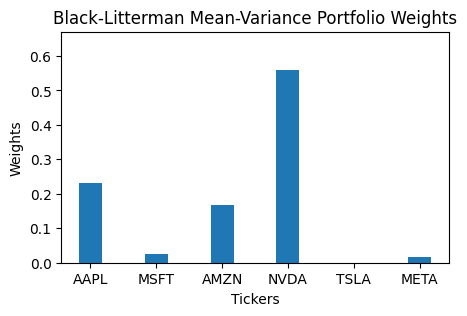

In [11]:
# Q1.6: Compute Black-Litterman mean-variance portfolio weights using μ_BL and Σ_BL

# Define portfolio weights as optimization variables
w_BL = cp.Variable(n)

# Constraints
constraints_BL = [
    cp.sum(w_BL) == 1,  # Weights sum to 1
    w_BL >= 0           # No short selling
]

# Objective: Maximize (return - lambda * variance)
# Using the same risk aversion parameter as in Q1.1 (supposed to be equal to sharpe ratio over 
# volatility of market)
portfolio_return_BL = mu_BL @ w_BL
portfolio_variance_BL = cp.quad_form(w_BL, Sigma_BL)

objective_BL = cp.Maximize(portfolio_return_BL - lambda_param * portfolio_variance_BL)

# Solve the optimization problem
problem_BL = cp.Problem(objective_BL, constraints_BL)
problem_BL.solve()

# Extract results
w_BL_optimal = w_BL.value
final_return_BL = mu_BL @ w_BL_optimal
final_variance_BL = w_BL_optimal @ Sigma_BL @ w_BL_optimal
final_volatility_BL = np.sqrt(final_variance_BL)

# Display results
df_BL_weights = pd.DataFrame({
    'Ticker': tickers_6,
    'BL_MV_Weight': w_BL_optimal,
    'Market_Weight': market_weights,
    'Markowitz_Weight': markowitz_weights
})

print("===== Black-Litterman Mean-Variance Weights =====")
print(f"Lambda (risk aversion): {lambda_param}")
print("\nOptimal weights:")
print(df_BL_weights)
print(f"\nExpected portfolio return (monthly): {final_return_BL:.4f}")
print(f"Portfolio variance: {final_variance_BL:.6f}")
print(f"Portfolio volatility (monthly): {final_volatility_BL:.4f}")

plt.figure(figsize=(5,3))
bar_width = 0.35
index = tickers_6
plt.bar(index, w_BL_optimal, bar_width, label='Black-Litterman Weights')
plt.title('Black-Litterman Mean-Variance Portfolio Weights')
plt.xlabel('Tickers')
plt.ylabel('Weights')
plt.ylim(0, max(w_BL_optimal)*1.2)
plt.show()

### Q1.7
Finally, compare the three sets of portfolio weights you have computed:
##### Markowitz mean-variance portfolio weights;
##### Capitalization-weighted (market) portfolio weights;
##### Black-Litterman mean-variance portfolio weights.
Which weights seem the most reasonable? Why?

===== COMPARISON OF THREE PORTFOLIO WEIGHTING APPROACHES =====

Ticker  Market_Weight  Markowitz_Weight  BL_Weight
  AAPL       0.303419          0.000000   0.230275
  MSFT       0.278205          0.000000   0.026269
  AMZN       0.138462          0.000000   0.168124
  NVDA       0.121368          0.751244   0.558577
  TSLA       0.079915          0.248756   0.000000
  META       0.078632          0.000000   0.016755

Sum of weights:
  Market:     1.0000
  Markowitz:  1.0000
  Black-Litterman: 1.0000


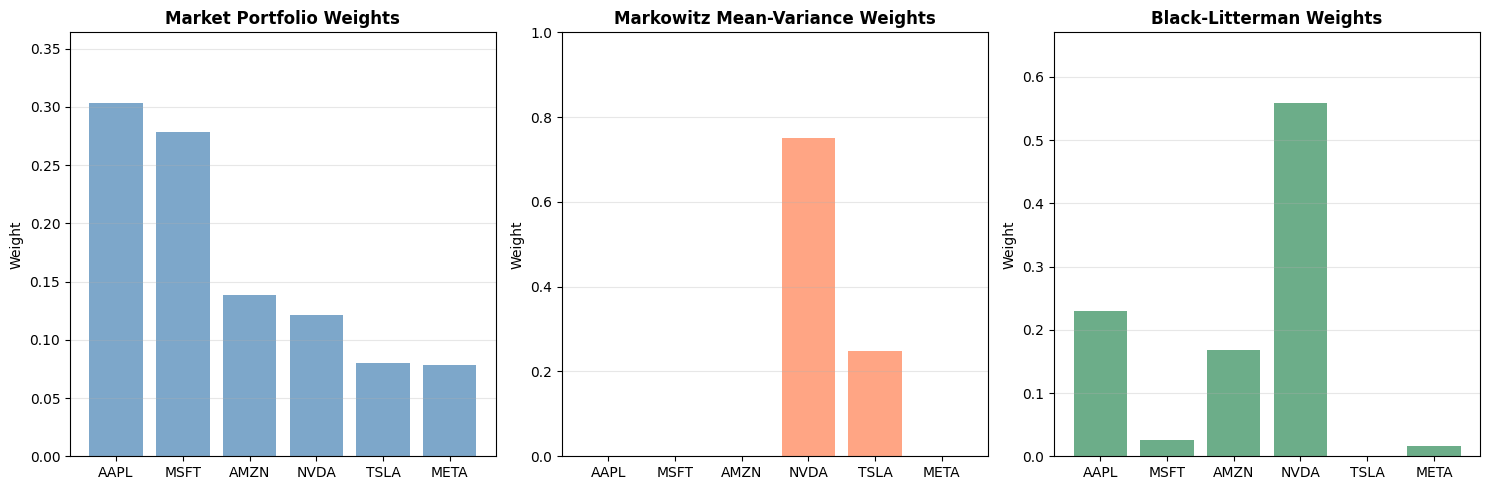


===== PORTFOLIO CHARACTERISTICS =====

      Portfolio  Expected_Return_Monthly  Expected_Return_Annual  Volatility_Monthly  Volatility_Annual  Sharpe_Ratio
         Market                 0.017504                0.210043            0.073280           0.253848      0.238861
      Markowitz                 0.024210                0.290517            0.071677           0.248297      0.337761
Black-Litterman                 0.008893                0.106719            0.061942           0.214573      0.143574


In [12]:
# Q1.7: Compare the three sets of portfolio weights

# Create a comprehensive comparison DataFrame
df_comparison = pd.DataFrame({
    'Ticker': tickers_6,
    'Market_Weight': market_weights,
    'Markowitz_Weight': markowitz_weights,
    'BL_Weight': w_BL_optimal
})

# Clean up near-zero weights for better readability
df_comparison['Markowitz_Weight'] = df_comparison['Markowitz_Weight'].apply(
    lambda x: 0.0 if abs(x) < 1e-10 else x
)
df_comparison['BL_Weight'] = df_comparison['BL_Weight'].apply(
    lambda x: 0.0 if abs(x) < 1e-10 else x
)

print("===== COMPARISON OF THREE PORTFOLIO WEIGHTING APPROACHES =====\n")
print(df_comparison.to_string(index=False))
print(f"\nSum of weights:")
print(f"  Market:     {df_comparison['Market_Weight'].sum():.4f}")
print(f"  Markowitz:  {df_comparison['Markowitz_Weight'].sum():.4f}")
print(f"  Black-Litterman: {df_comparison['BL_Weight'].sum():.4f}")

# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Market weights
axes[0].bar(tickers_6, market_weights, color='steelblue', alpha=0.7)
axes[0].set_title('Market Portfolio Weights', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Weight')
axes[0].set_ylim([0, max(market_weights) * 1.2])
axes[0].grid(axis='y', alpha=0.3)

# Markowitz weights
axes[1].bar(tickers_6, [max(0, w) for w in markowitz_weights], color='coral', alpha=0.7)
axes[1].set_title('Markowitz Mean-Variance Weights', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)

# Black-Litterman weights
axes[2].bar(tickers_6, [max(0, w) for w in w_BL_optimal], color='seagreen', alpha=0.7)
axes[2].set_title('Black-Litterman Weights', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Weight')
axes[2].set_ylim([0, max(w_BL_optimal) * 1.2])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Compute portfolio characteristics for each approach
print("\n===== PORTFOLIO CHARACTERISTICS =====\n")

# Market portfolio
ret_market = mu @ w_m
vol_market = np.sqrt(w_m @ Sigma @ w_m)
sharpe_market = ret_market / vol_market if vol_market > 0 else 0

# Markowitz portfolio
ret_markowitz = final_return
vol_markowitz = final_volatility
sharpe_markowitz = ret_markowitz / vol_markowitz if vol_markowitz > 0 else 0

# Black-Litterman portfolio
ret_BL = final_return_BL
vol_BL = final_volatility_BL
sharpe_BL = ret_BL / vol_BL if vol_BL > 0 else 0

df_characteristics = pd.DataFrame({
    'Portfolio': ['Market', 'Markowitz', 'Black-Litterman'],
    'Expected_Return_Monthly': [ret_market, ret_markowitz, ret_BL],
    'Expected_Return_Annual': [ret_market * 12, ret_markowitz * 12, ret_BL * 12],
    'Volatility_Monthly': [vol_market, vol_markowitz, vol_BL],
    'Volatility_Annual': [vol_market * np.sqrt(12), vol_markowitz * np.sqrt(12), vol_BL * np.sqrt(12)],
    'Sharpe_Ratio': [sharpe_market, sharpe_markowitz, sharpe_BL]
})

print(df_characteristics.to_string(index=False))


### Portfolio Weights and Returns Analysis

**Market Portfolio**  
- **Weights**: Diversified according to market capitalization; no extreme allocations.  
- **Returns**: Monthly return = 1.75%, monthly volatility = 7.33%, Sharpe ratio = 0.239. Safe and well-diversified, but not very efficient in terms of risk-adjusted return.  

**Markowitz Portfolio**  
- **Weights**: Highly concentrated on NVDA (75%) and TSLA (25%); other assets are zero.  
- **Returns**: Monthly return = 2.42%, monthly volatility = 7.17%, Sharpe ratio = 0.338. Mathematically optimal for risk-adjusted return, but very risky in practice due to extreme concentration.  

**Black-Litterman Portfolio**  
- **Weights**: Balanced between market and Markowitz, maintaining better diversification.  
- **Returns**: Monthly return = 0.89% (very low compared to other portfolios), monthly volatility = 6.19%, Sharpe ratio ≈ 0.144. More diversified and stable than Markowitz, but lower risk-adjusted performance than the market.  

**Summary:**  
- **Markowitz**: Highest Sharpe ratio but very concentrated → high risk.  
- **Market**: Moderate Sharpe ratio, well-diversified → safe and realistic.  
- **Black-Litterman**: Most diversified and balanced → safer but less efficient in terms of return per unit of risk (weird??).

**Possible reasons for Black-Litterman’s low Sharpe ratio (we obtained very low retruns compared to the market portfolio):**  
1. **Our views are too pessimistic compared to market** – if expected returns for some assets are low, the portfolio favors safety over return.  
2. **Over-reduction of high-performing assets** – key market performers may get very low weights, lowering portfolio returns.  
3. **Our Tau resulted in high confidence in our pessimistic views** – tau controls the confidence in the market vs. views; a wrong value can make BL underperform.
